# Przygotowanie danych
Przygotowanie danych wejściowych jako jeden obraz 3 kanałowy złączony z rysunku dziecka + planszy + gradient_difference_map

In [ ]:
import json
import io
import shutil
from pathlib import Path

import cairosvg
import cv2
import numpy as np
from PIL import Image


def setup_directories():
    processed_dir = Path("../data/processed/3d-input-data")
    processed_dir.mkdir(parents=True, exist_ok=True)
    return processed_dir


def render_svg_to_array(svg_path, width, height):
    try:
        png_data = cairosvg.svg2png(
            url=str(svg_path),
            output_width=width,
            output_height=height,
            background_color="white"
        )
        image = Image.open(io.BytesIO(png_data)).convert("L")
        img_np = np.array(image)
        _, pattern_bin = cv2.threshold(img_np, 200, 255, cv2.THRESH_BINARY_INV)
        return pattern_bin
    except Exception as e:
        print(f"Błąd renderowania SVG {svg_path}: {e}")
        return None


def draw_strokes(strokes, width, height):
    img = np.zeros((height, width), dtype=np.uint8)
    for stroke in strokes:
        points = [[int(p[2]), int(p[3])] for p in stroke]
        if len(points) > 1:
            points = np.array(points, dtype=np.int32)
            cv2.polylines(img, [points], isClosed=False, color=255, thickness=2)
    return img


def process_drawing(drawing_info, summary_path, pattern_dir, output_base_dir):
    display_info = drawing_info.get("display_info")
    if not display_info:
        return

    win_w, win_h = display_info["window_width"], display_info["window_height"]
    img_w, img_h = display_info["image_width"], display_info["image_height"]
    off_x, off_y = display_info["offset_x"], display_info["offset_y"]

    child_img_full = draw_strokes(drawing_info["strokes_data"], win_w, win_h)

    pattern_idx = drawing_info["index"]
    pattern_path = pattern_dir / f"bvrt_c_{pattern_idx}.svg"
    if not pattern_path.exists():
        print(f"Brak wzorca: {pattern_path}")
        return

    pattern_img_small = render_svg_to_array(pattern_path, img_w, img_h)
    if pattern_img_small is None:
        return

    full_pattern = np.zeros((win_h, win_w), dtype=np.uint8)
    h_to_paste = min(img_h, win_h - off_y)
    w_to_paste = min(img_w, win_w - off_x)
    full_pattern[off_y:off_y + h_to_paste, off_x:off_x + w_to_paste] = pattern_img_small[:h_to_paste, :w_to_paste]

    child_blur = cv2.GaussianBlur(child_img_full, (5, 5), 0)
    pattern_blur = cv2.GaussianBlur(full_pattern, (5, 5), 0)
    diff_map = cv2.absdiff(child_blur, pattern_blur)

    # Zapisujemy jawny RGB: R=Child, G=Pattern, B=Diff. Nie używamy cv2.imwrite,
    # bo OpenCV interpretuje kanały jako BGR i odwracałoby semantykę wejścia.
    combined_rgb = np.stack([child_img_full, full_pattern, diff_map], axis=-1)

    patient_name = summary_path.parent.parent.name
    test_id = summary_path.parent.name
    patient_output_dir = output_base_dir / patient_name
    patient_output_dir.mkdir(parents=True, exist_ok=True)

    for filename in ["summary.json", "labels.json"]:
        src = summary_path.parent / filename
        dst = patient_output_dir / filename
        if src.exists() and not dst.exists():
            shutil.copy(str(src), str(dst))

    out_filename = f"{patient_name}_{test_id}_p{pattern_idx}.png"
    Image.fromarray(combined_rgb, mode="RGB").save(patient_output_dir / out_filename)


def run_preprocessing():
    raw_dir = Path("../data/raw")
    pattern_dir = Path("../data/patterns")
    output_base_dir = setup_directories()

    test_dirs = sorted(raw_dir.glob("*/*"))
    for test_dir in test_dirs:
        summary_path = test_dir / "summary.json"
        if summary_path.exists():
            print(f"Przetwarzanie {test_dir}...")
            with open(summary_path, "r", encoding="utf-8") as f:
                data = json.load(f)
            for drawing in data.get("drawings", []):
                process_drawing(drawing, summary_path, pattern_dir, output_base_dir)


# Uruchom tę komórkę ponownie po zmianie preprocesingu, żeby odtworzyć PNG z poprawnym porządkiem kanałów.
run_preprocessing()


# Analiza błędów (Statystyki)
Wizualizacja średniego błędu (kanał Diff) w zależności od pacjenta i trudności zadania (indeks wzorca).

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
import numpy as np
import cv2
import cairosvg
import io


def collect_stats(base_dir):
    data = []
    base_path = Path(base_dir)
    for patient_dir in base_path.iterdir():
        if not patient_dir.is_dir(): continue
        patient_name = patient_dir.name
        for img_path in patient_dir.glob("*.png"):
            match = re.search(r'_p(\d+)\.png$', img_path.name)
            if not match: continue
            pattern_idx = int(match.group(1))
            img = cv2.imread(str(img_path))
            if img is None: continue
            mean_error = img[:, :, 2].mean()  # Kanał 3 (Diff)
            data.append({'Patient': patient_name, 'Pattern_Index': pattern_idx, 'Mean_Error': mean_error})
    return pd.DataFrame(data)


# Załadowanie statystyk z przetworzonych obrazów
df_stats = collect_stats("../data/processed/3d-input-data")


### 1. Globalna analiza błędu rysowania (Boxploty)
Pokazuje rozkład błędów dla każdego pacjenta. Pacjenci są posortowani według mediany błędu.

/tmp/ipykernel_44716/1310029197.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Patient', y='Mean_Error', data=df_stats, order=order, palette='viridis')


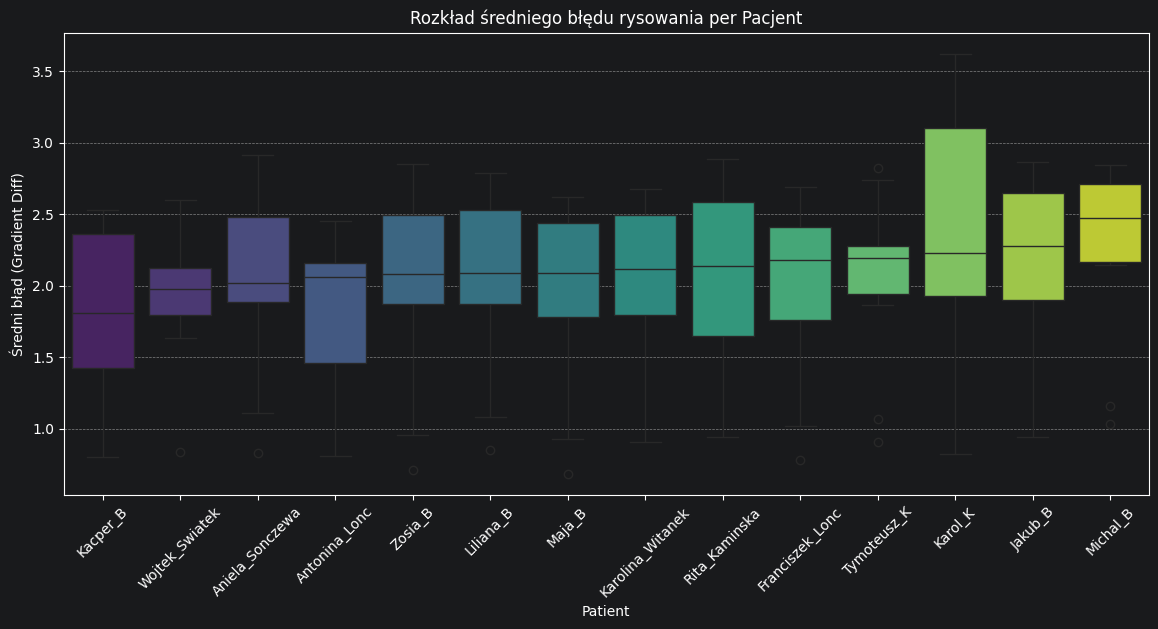

In [7]:
if not df_stats.empty:
    plt.figure(figsize=(14, 6))
    order = df_stats.groupby('Patient')['Mean_Error'].median().sort_values().index
    sns.boxplot(x='Patient', y='Mean_Error', data=df_stats, order=order, palette='viridis')
    plt.xticks(rotation=45)
    plt.title('Rozkład średniego błędu rysowania per Pacjent')
    plt.ylabel('Średni błąd (Gradient Diff)')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()


### 4. Profil trudności testu (Line Chart)
Pokazuje jak średni błąd zmienia się wraz z kolejnymi (trudniejszymi) wzorcami BVRT.

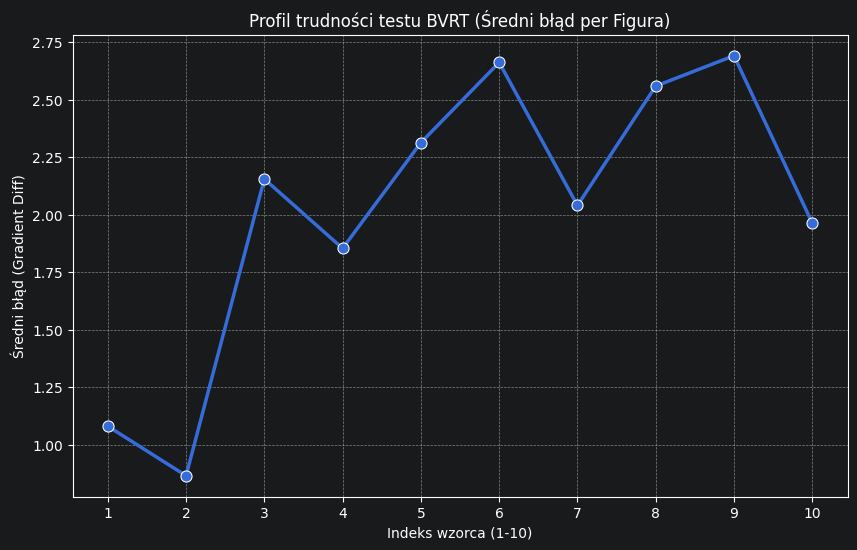

In [8]:
if not df_stats.empty:
    plt.figure(figsize=(10, 6))
    difficulty_profile = df_stats.groupby('Pattern_Index')['Mean_Error'].mean().reset_index()
    sns.lineplot(x='Pattern_Index', y='Mean_Error', data=difficulty_profile, marker='o', linewidth=2.5, markersize=8)
    plt.title('Profil trudności testu BVRT (Średni błąd per Figura)')
    plt.xlabel('Indeks wzorca (1-10)')
    plt.ylabel('Średni błąd (Gradient Diff)')
    plt.xticks(range(1, 11))
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()


# Rurociąg PyTorch (Dataset & DataLoader)
Definicja klasy Dataset, transformacji oraz strategii walidacji Leave-One-Subject-Out (LOSO).

In [9]:
import json
import random
import re
from pathlib import Path

import numpy as np
import torch
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms


ERROR_CATEGORIES = [
    "omissions", "distortions", "perseverations",
    "rotations", "displacements", "relative_size_errors"
]


class ResizeLongSideAndPad:
    """Zachowuje geometrię BVRT: resize dłuższego boku + czarny padding do kwadratu."""

    def __init__(self, size=224, fill=0):
        self.size = size
        self.fill = fill

    def __call__(self, image):
        image = image.convert("RGB")
        width, height = image.size
        scale = self.size / max(width, height)
        new_width = max(1, int(round(width * scale)))
        new_height = max(1, int(round(height * scale)))
        resized = image.resize((new_width, new_height), Image.BILINEAR)
        canvas = Image.new("RGB", (self.size, self.size), (self.fill, self.fill, self.fill))
        left = (self.size - new_width) // 2
        top = (self.size - new_height) // 2
        canvas.paste(resized, (left, top))
        return canvas


class BVRTDataset(Dataset):
    """
    Dataset BVRT dla 3-kanałowego wejścia: R=Child, G=Pattern, B=Diff.
    Target to multi-label 1/0: czy dany typ błędu wystąpił przynajmniej raz.
    """

    def __init__(self, root_dir, patient_ids=None, transform=None):
        self.root_dir = Path(root_dir)
        self.transform = transform
        self.samples = []
        self.error_categories = ERROR_CATEGORIES

        if not self.root_dir.exists():
            raise FileNotFoundError(f"Brak katalogu danych: {self.root_dir}")

        patients = sorted([d for d in self.root_dir.iterdir() if d.is_dir()])
        if patient_ids:
            patients = [d for d in patients if d.name in patient_ids]

        for patient_dir in patients:
            labels_file = patient_dir / "labels.json"
            if not labels_file.exists():
                print(f"Warning: missing labels.json in {patient_dir}")
                continue

            with open(labels_file, "r", encoding="utf-8") as f:
                labels_data = json.load(f)
            drawings_labels = {d["drawing_id"]: d["errors"] for d in labels_data["drawings"]}

            for img_path in sorted(patient_dir.glob("*.png")):
                match = re.search(r"_p(\d+)\.png$", img_path.name)
                if not match:
                    continue
                drawing_idx = int(match.group(1))
                if drawing_idx in drawings_labels:
                    self.samples.append({
                        "img_path": img_path,
                        "labels": drawings_labels[drawing_idx],
                        "patient": patient_dir.name,
                        "drawing_idx": drawing_idx,
                    })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        image = Image.open(sample["img_path"]).convert("RGB")
        if self.transform:
            image = self.transform(image)

        target = torch.tensor([
            1.0 if sample["labels"].get(cat, 0) > 0 else 0.0
            for cat in self.error_categories
        ], dtype=torch.float32)
        return image, target

    def get_labels(self):
        labels = []
        for sample in self.samples:
            labels.append([
                1.0 if sample["labels"].get(cat, 0) > 0 else 0.0
                for cat in self.error_categories
            ])
        return torch.tensor(labels, dtype=torch.float32)

    def get_pos_weights(self):
        labels = self.get_labels()
        positives = labels.sum(dim=0)
        negatives = len(self.samples) - positives
        return negatives / (positives + 1e-6)


def build_transforms(image_size=224):
    normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    train_transform = transforms.Compose([
        ResizeLongSideAndPad(size=image_size, fill=0),
        transforms.ColorJitter(brightness=0.05, contrast=0.05),
        transforms.RandomAffine(degrees=1, translate=(0.01, 0.01), scale=(0.99, 1.01), fill=0),
        transforms.ToTensor(),
        normalize,
    ])
    eval_transform = transforms.Compose([
        ResizeLongSideAndPad(size=image_size, fill=0),
        transforms.ToTensor(),
        normalize,
    ])
    return train_transform, eval_transform


train_transforms, val_transforms = build_transforms(image_size=224)


### Dobre praktyki dla małych zbiorów medycznych (BVRT)
1. **Zapobieganie Overfittingowi**:
   - Używaj silnej regularyzacji (Dropout przed warstwą FC).
   - Zamrażaj większość wag pre-trained (Transfer Learning).
   - Wczesne zatrzymywanie (Early Stopping) monitorowane na metryce F1 Macro (nie na Loss).
2. **Specyfika Augmentacji**:
   - Unikaj dużych rotacji (> 5-10 stopni) i odbić lustrzanych – w BVRT kierunek i orientacja to kluczowe błędy (`rotations`, `displacements`).
   - `RandomAffine` z bardzo małymi wartościami jest bezpieczniejszy.
3. **Interpretowalność**:
   - Zastosuj Grad-CAM, aby sprawdzić, czy sieć faktycznie "patrzy" na błędy (kanał Diff), czy na artefakty tła.
4. **Walidacja LOSO**:
   - Zawsze raportuj wyniki uśrednione po wszystkich pacjentach (mean over LOSO folds).


# Zaawansowana analiza etykiet
Agregacja danych z plików `labels.json` oraz wizualizacja rozkładu błędów neuropsychologicznych.

In [11]:
def load_detailed_labels(root_dir):
    import pandas as pd
    import json
    from pathlib import Path

    root_path = Path(root_dir)
    all_errors = []

    # Przeszukujemy foldery pacjentów w poszukiwaniu labels.json
    for labels_file in root_path.glob('*/labels.json'):
        patient_name = labels_file.parent.name
        with open(labels_file, 'r', encoding='utf-8') as f:
            data = json.load(f)
            for d in data['drawings']:
                err_dict = d['errors'].copy()
                err_dict['patient'] = patient_name
                err_dict['drawing_id'] = d['drawing_id']
                err_dict['total_errors'] = d['total_errors']
                all_errors.append(err_dict)

    return pd.DataFrame(all_errors)


# Ładowanie danych
df_labels = load_detailed_labels("../data/processed/3d-input-data")
error_cols = ['omissions', 'distortions', 'perseverations', 'rotations', 'displacements', 'relative_size_errors']

df_labels.head()

,omissions,distortions,perseverations,rotations,displacements,relative_size_errors,patient,drawing_id,total_errors
0,0,1,0,0,1,1,Liliana_B,1,3
1,0,2,0,0,2,1,Liliana_B,2,5
2,1,2,0,0,2,1,Liliana_B,3,6
3,0,2,0,0,2,2,Liliana_B,4,6
4,1,3,1,1,3,2,Liliana_B,5,11


### 1. Rozkład typów błędów (Bar Chart)
Łączna liczba wystąpień każdego błędu w całym zbiorze danych.

=== LICZBA WYSTĄPIEŃ POSZCZEGÓLNYCH BŁĘDÓW ===
distortions              : 311 os.
displacements            : 299 os.
relative_size_errors     : 220 os.
omissions                : 52 os.
perseverations           : 37 os.
rotations                : 30 os.


/tmp/ipykernel_44716/490491496.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=error_counts.values, y=error_counts.index, palette='magma')


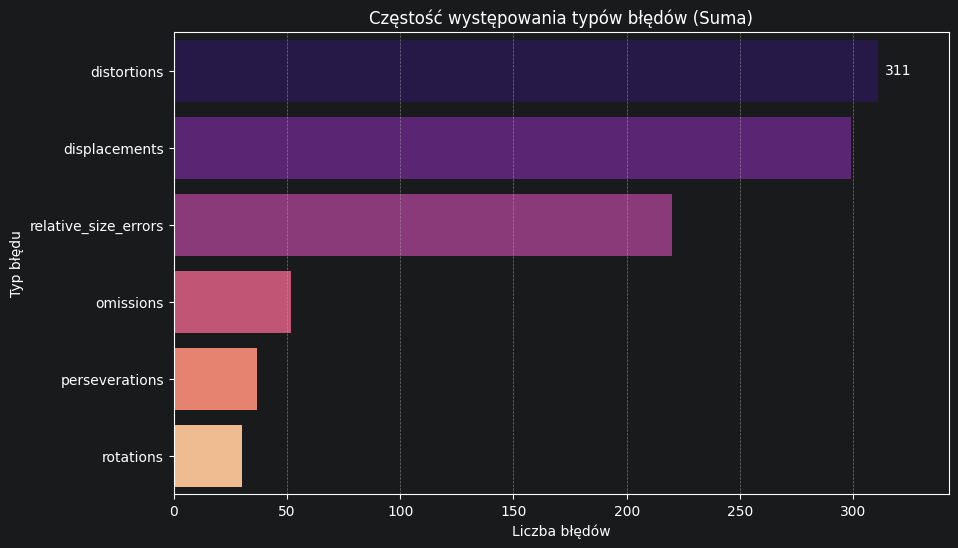

In [12]:
if not df_labels.empty:
    # Obliczenie sumy błędów i posortowanie malejąco
    error_counts = df_labels[error_cols].sum().sort_values(ascending=False)

    # 1. WYPISYWANIE TEKSTOWE W NOTEBOOKU
    print("=== LICZBA WYSTĄPIEŃ POSZCZEGÓLNYCH BŁĘDÓW ===")
    for error_type, count in error_counts.items():
        print(f"{error_type:<25}: {int(count)} os.")
    print("=" * 46)

    # 2. WIZUALIZACJA GRAPH
    plt.figure(figsize=(10, 6))

    # Przypisujemy wykres do zmiennej 'ax', aby móc nim manipulować
    ax = sns.barplot(x=error_counts.values, y=error_counts.index, palette='magma')

    # Dodanie wartości liczbowych na końcach słupków
    ax.bar_label(ax.containers[0], fmt='%d', padding=5)

    plt.title('Częstość występowania typów błędów (Suma)')
    plt.xlabel('Liczba błędów')
    plt.ylabel('Typ błędu')

    # Lekkie zwiększenie limitu osi X, aby wartości tekstowe bar_label nie wychodziły poza wykres
    plt.xlim(0, error_counts.max() * 1.1)

    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.show()

### 2. Korelacja między typami błędów (Heatmap)
Jak silnie poszczególne błędy współwystępują ze sobą.

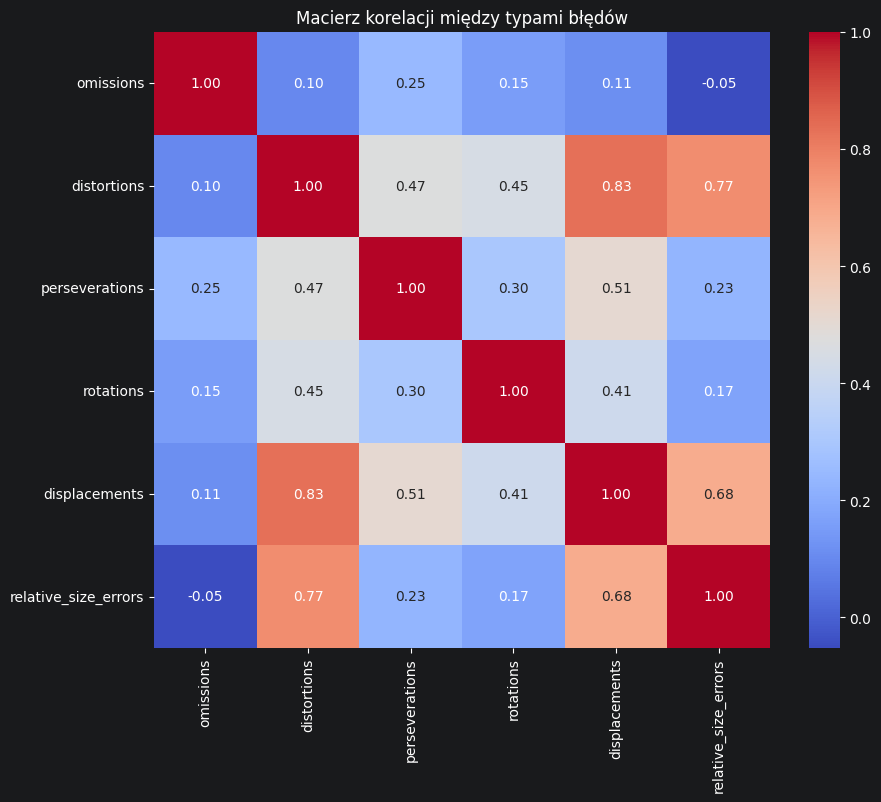

In [13]:
if not df_labels.empty:
    plt.figure(figsize=(10, 8))
    sns.heatmap(df_labels[error_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', square=True)
    plt.title('Macierz korelacji między typami błędów')
    plt.show()

### 3. Profil błędów per Figura (Grouped Bar Chart)
Analiza trudności każdego z 10 wzorców BVRT.

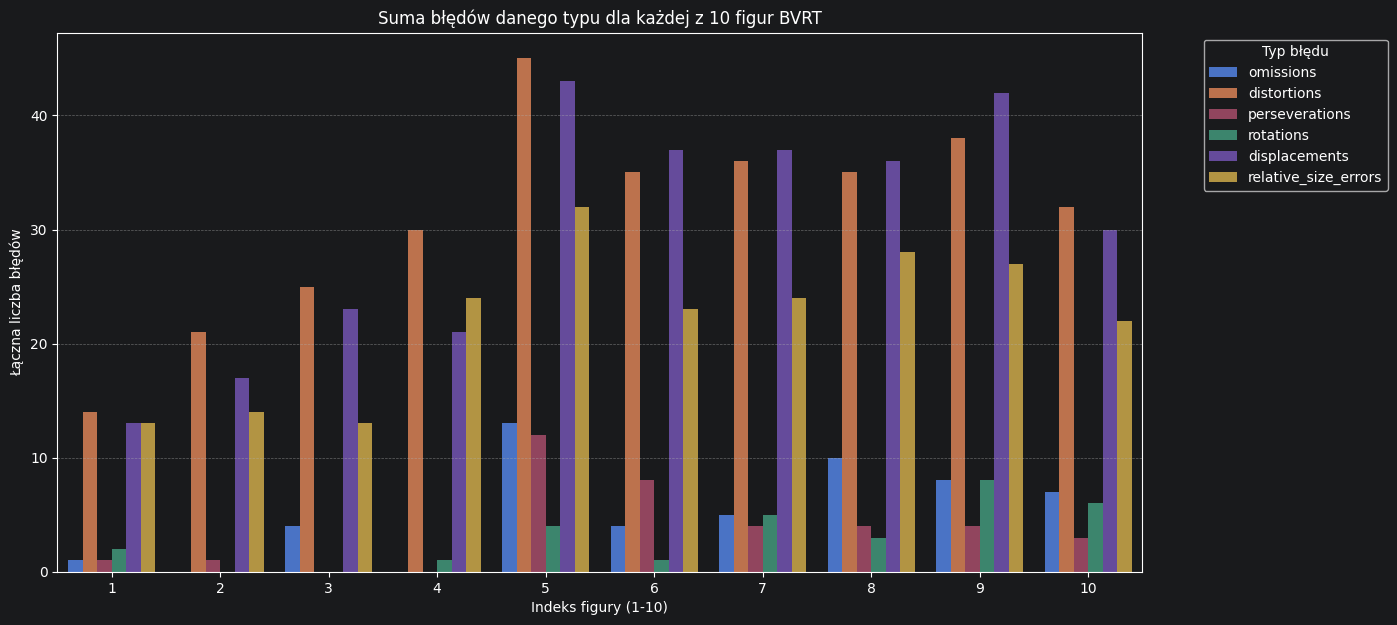

In [14]:
if not df_labels.empty:
    df_melted = df_labels.melt(id_vars=['drawing_id'], value_vars=error_cols, var_name='error_type', value_name='count')
    plt.figure(figsize=(14, 7))
    sns.barplot(x='drawing_id', y='count', hue='error_type', data=df_melted, estimator=np.sum, errorbar=None)
    plt.title('Suma błędów danego typu dla każdej z 10 figur BVRT')
    plt.xlabel('Indeks figury (1-10)')
    plt.ylabel('Łączna liczba błędów')
    plt.legend(title='Typ błędu', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.show()

# Budowa modelu ResNet18 (Transfer Learning)
Definicja architektury sieci ResNet18 z zamrożonymi warstwami bazowymi i nową głową klasyfikacyjną dla zadania multi-label.

In [15]:
import torch
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights


class ResNet18Transfer(nn.Module):
    """ResNet18 transfer learning baseline dla BVRT multi-label classification."""

    def __init__(self, num_classes=6, freeze_backbone=True, unfreeze_layer4=False, dropout=0.4, pretrained=True):
        super().__init__()
        weights = ResNet18_Weights.DEFAULT if pretrained else None
        self.model = resnet18(weights=weights)

        for param in self.model.parameters():
            param.requires_grad = not freeze_backbone

        if unfreeze_layer4:
            for param in self.model.layer4.parameters():
                param.requires_grad = True

        in_features = self.model.fc.in_features
        self.model.fc = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, num_classes),
        )

    def freeze_backbone_batchnorm(self):
        # Przy head-only transfer learning BatchNorm backbone'u nie powinien aktualizować statystyk.
        for module in [self.model.bn1, *self.model.layer1, *self.model.layer2, *self.model.layer3, *self.model.layer4]:
            if isinstance(module, nn.BatchNorm2d):
                module.eval()
            else:
                for submodule in module.modules():
                    if isinstance(submodule, nn.BatchNorm2d):
                        submodule.eval()

    def forward(self, x):
        return self.model(x)


### Konfiguracja procesu uczenia
Ustawienie funkcji straty BCEWithLogitsLoss oraz optymalizatora Adam tylko dla parametrów ostatniej warstwy.

In [16]:
import csv
from pathlib import Path
from typing import Any, Dict, List, Sequence, Tuple

import numpy as np
from sklearn.metrics import accuracy_score, f1_score, hamming_loss, precision_recall_fscore_support


class BVRTTrainer:
    def __init__(self, model, criterion, optimizer, device):
        self.model = model.to(device)
        self.criterion = criterion
        self.optimizer = optimizer
        self.device = device

    def train_one_epoch(self, train_loader):
        self.model.train()
        if hasattr(self.model, "freeze_backbone_batchnorm"):
            self.model.freeze_backbone_batchnorm()

        running_loss = 0.0
        for images, labels in train_loader:
            images = images.to(self.device)
            labels = labels.to(self.device)
            self.optimizer.zero_grad()
            logits = self.model(images)
            loss = self.criterion(logits, labels)
            loss.backward()
            self.optimizer.step()
            running_loss += loss.item() * images.size(0)
        return running_loss / len(train_loader.dataset)

    def evaluate(self, loader):
        self.model.eval()
        running_loss = 0.0
        all_probs = []
        all_labels = []
        with torch.no_grad():
            for images, labels in loader:
                images = images.to(self.device)
                labels = labels.to(self.device)
                logits = self.model(images)
                loss = self.criterion(logits, labels)
                probs = torch.sigmoid(logits)
                running_loss += loss.item() * images.size(0)
                all_probs.append(probs.cpu().numpy())
                all_labels.append(labels.cpu().numpy())
        return running_loss / len(loader.dataset), np.vstack(all_probs), np.vstack(all_labels)


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def apply_thresholds(probs, thresholds):
    return (probs >= thresholds.reshape(1, -1)).astype(int)


def tune_thresholds(probs, labels, threshold_grid):
    thresholds = np.full(labels.shape[1], 0.5, dtype=np.float32)
    details = {}
    for idx, label_name in enumerate(ERROR_CATEGORIES):
        support = int(labels[:, idx].sum())
        if support == 0:
            details[label_name] = {
                "threshold": 0.5,
                "best_f1": 0.0,
                "fallback": "no_positive_validation_samples",
            }
            continue

        best_threshold = 0.5
        best_f1 = -1.0
        for threshold in threshold_grid:
            pred = (probs[:, idx] >= threshold).astype(int)
            score = f1_score(labels[:, idx], pred, zero_division=0)
            if score > best_f1:
                best_f1 = score
                best_threshold = threshold

        thresholds[idx] = float(best_threshold)
        details[label_name] = {
            "threshold": float(best_threshold),
            "best_f1": float(best_f1),
            "fallback": None,
        }
    return thresholds, details


def compute_multilabel_metrics(labels, preds_binary, thresholds, strategy):
    precision, recall, f1, support = precision_recall_fscore_support(
        labels, preds_binary, average=None, zero_division=0
    )
    per_label = {}
    for idx, label_name in enumerate(ERROR_CATEGORIES):
        per_label[label_name] = {
            "precision": float(precision[idx]),
            "recall": float(recall[idx]),
            "f1": float(f1[idx]),
            "support": int(support[idx]),
            "actual_positives": int(labels[:, idx].sum()),
            "predicted_positives": int(preds_binary[:, idx].sum()),
            "true_positive_matches": int(((labels[:, idx] == 1) & (preds_binary[:, idx] == 1)).sum()),
            "threshold": float(thresholds[idx]),
        }

    return {
        "strategy": strategy,
        "macro_f1": float(f1_score(labels, preds_binary, average="macro", zero_division=0)),
        "micro_f1": float(f1_score(labels, preds_binary, average="micro", zero_division=0)),
        "weighted_f1": float(f1_score(labels, preds_binary, average="weighted", zero_division=0)),
        "hamming_loss": float(hamming_loss(labels, preds_binary)),
        "subset_accuracy": float(accuracy_score(labels, preds_binary)),
        "per_label": per_label,
    }


def labels_from_dataset(dataset):
    return dataset.get_labels().numpy()


def majority_baseline_vector(reference_labels):
    return (reference_labels.mean(axis=0) >= 0.5).astype(np.float32)


def constant_predictions(labels, vector):
    return np.tile(vector.reshape(1, -1), (labels.shape[0], 1)).astype(int)


def write_json(path, payload):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(payload, f, indent=2, ensure_ascii=False)


def write_csv(path, rows, fieldnames):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)


# Walidacja Leave-One-Subject-Out (LOSO)
Ten proces trenuje osobny model dla każdego pacjenta, używając go jako zbioru walidacyjnego, a pozostałych pacjentów jako zbioru treningowego. Gwarantuje to brak wycieku danych pacjenta.

In [18]:
import copy
import json
from pathlib import Path

import torch
from torch.utils.data import DataLoader


def select_validation_patient(train_candidates, fold_idx):
    candidates = sorted(train_candidates)
    return candidates[fold_idx % len(candidates)]


def sanity_check_splits(train_patients, val_patient, test_patient):
    train_set = set(train_patients)
    val_set = {val_patient}
    test_set = {test_patient}
    if train_set & val_set or train_set & test_set or val_set & test_set:
        raise ValueError(f"Patient leakage: train={train_patients}, val={val_patient}, test={test_patient}")


def flatten_fold_metrics(fold_metrics):
    rows = []
    for fold in fold_metrics:
        for strategy, metrics in fold["test_metrics"].items():
            rows.append({
                "fold": fold["fold"],
                "test_patient": fold["test_patient"],
                "val_patient": fold["val_patient"],
                "strategy": strategy,
                "macro_f1": metrics["macro_f1"],
                "micro_f1": metrics["micro_f1"],
                "weighted_f1": metrics["weighted_f1"],
                "hamming_loss": metrics["hamming_loss"],
                "subset_accuracy": metrics["subset_accuracy"],
                "best_val_loss": fold["best_val_loss"],
                "epochs_trained": fold["epochs_trained"],
            })
    return rows


def flatten_per_label_metrics(fold_metrics):
    rows = []
    for fold in fold_metrics:
        for strategy, metrics in fold["test_metrics"].items():
            for label_name, values in metrics["per_label"].items():
                row = {
                    "fold": fold["fold"],
                    "test_patient": fold["test_patient"],
                    "val_patient": fold["val_patient"],
                    "strategy": strategy,
                    "label": label_name,
                }
                row.update(values)
                rows.append(row)
    return rows


def summarize_results(fold_metrics, config):
    summary = {"config": config, "strategies": {}}
    strategies = sorted(fold_metrics[0]["test_metrics"].keys()) if fold_metrics else []
    for strategy in strategies:
        strategy_metrics = [fold["test_metrics"][strategy] for fold in fold_metrics]
        summary["strategies"][strategy] = {}
        for metric_name in ["macro_f1", "micro_f1", "weighted_f1", "hamming_loss", "subset_accuracy"]:
            values = np.array([m[metric_name] for m in strategy_metrics], dtype=np.float32)
            summary["strategies"][strategy][f"{metric_name}_mean"] = float(values.mean())
            summary["strategies"][strategy][f"{metric_name}_std"] = float(values.std())

        per_label = {}
        for label_name in ERROR_CATEGORIES:
            f1_values = np.array([m["per_label"][label_name]["f1"] for m in strategy_metrics], dtype=np.float32)
            per_label[label_name] = {
                "f1_mean": float(f1_values.mean()),
                "f1_std": float(f1_values.std()),
            }
        summary["strategies"][strategy]["per_label"] = per_label
    return summary


def run_loso_training_scientific(
    root_dir,
    results_dir="../results/3d-input-resnet",
    num_epochs=25,
    early_stopping_patience=4,
    batch_size=8,
    learning_rate=3e-4,
    weight_decay=1e-4,
    image_size=224,
    seed=42,
    unfreeze_layer4=False,
    dropout=0.4,
):
    set_seed(seed)
    root_path = Path(root_dir)
    patients = sorted([d.name for d in root_path.iterdir() if d.is_dir()])
    if len(patients) < 3:
        raise ValueError("Nested LOSO wymaga co najmniej 3 pacjentów.")

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    train_transform, eval_transform = build_transforms(image_size=image_size)
    threshold_grid = [round(x, 2) for x in np.arange(0.05, 1.0, 0.05)]

    results_path = Path(results_dir)
    results_path.mkdir(parents=True, exist_ok=True)

    config = {
        "model": "ResNet18Transfer",
        "pretrained": True,
        "training": "head_only_transfer_learning" if not unfreeze_layer4 else "layer4_finetuning",
        "input_channels": "RGB_semantics_R_child_G_pattern_B_diff",
        "image_resize": {
            "method": "resize_long_side_then_black_pad",
            "image_size": image_size,
            "preserve_aspect_ratio": True,
        },
        "num_epochs": num_epochs,
        "early_stopping_patience": early_stopping_patience,
        "batch_size": batch_size,
        "learning_rate": learning_rate,
        "weight_decay": weight_decay,
        "seed": seed,
        "threshold_grid": threshold_grid,
        "patients": patients,
        "labels": ERROR_CATEGORIES,
        "device": str(device),
    }
    write_json(results_path / "experiment_config.json", config)

    full_ds = BVRTDataset(root_dir, transform=eval_transform)
    print(f"Dataset sanity check: {len(full_ds)} próbek, {len(patients)} pacjentów.")

    fold_metrics = []
    for fold_idx, test_patient in enumerate(patients):
        candidates = [p for p in patients if p != test_patient]
        val_patient = select_validation_patient(candidates, fold_idx)
        train_patients = [p for p in candidates if p != val_patient]
        sanity_check_splits(train_patients, val_patient, test_patient)

        print("\n" + "=" * 72)
        print(f"Fold {fold_idx + 1}/{len(patients)}")
        print(f"Train patients: {train_patients}")
        print(f"Validation patient: {val_patient}")
        print(f"Test patient: {test_patient}")

        train_ds = BVRTDataset(root_dir, patient_ids=train_patients, transform=train_transform)
        val_ds = BVRTDataset(root_dir, patient_ids=[val_patient], transform=eval_transform)
        test_ds = BVRTDataset(root_dir, patient_ids=[test_patient], transform=eval_transform)

        generator = torch.Generator()
        generator.manual_seed(seed + fold_idx)
        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, generator=generator)
        val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
        test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

        pos_weight = train_ds.get_pos_weights().to(device)
        criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        model = ResNet18Transfer(
            num_classes=len(ERROR_CATEGORIES),
            freeze_backbone=True,
            unfreeze_layer4=unfreeze_layer4,
            dropout=dropout,
        )
        optimizer = torch.optim.AdamW(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=learning_rate,
            weight_decay=weight_decay,
        )
        trainer = BVRTTrainer(model, criterion, optimizer, device)

        best_val_loss = float("inf")
        best_model_wts = copy.deepcopy(model.state_dict())
        patience_counter = 0
        history = []

        for epoch in range(num_epochs):
            train_loss = trainer.train_one_epoch(train_loader)
            val_loss, val_probs, val_labels = trainer.evaluate(val_loader)
            val_preds_05 = apply_thresholds(val_probs, np.full(len(ERROR_CATEGORIES), 0.5))
            val_macro_f1 = f1_score(val_labels, val_preds_05, average="macro", zero_division=0)

            improved = val_loss < best_val_loss
            if improved:
                best_val_loss = val_loss
                best_model_wts = copy.deepcopy(model.state_dict())
                patience_counter = 0
            else:
                patience_counter += 1

            history.append({
                "epoch": epoch + 1,
                "train_loss": float(train_loss),
                "val_loss": float(val_loss),
                "val_macro_f1_threshold_0_5": float(val_macro_f1),
                "checkpoint_selected": improved,
            })
            print(
                f"E{epoch + 1:02d} | train_loss={train_loss:.4f} | "
                f"val_loss={val_loss:.4f} | val_macro_f1@0.5={val_macro_f1:.4f} "
                f"{'*New Best*' if improved else ''}"
            )

            if patience_counter >= early_stopping_patience:
                print(f"Early stopping po {epoch + 1} epokach.")
                break

        model.load_state_dict(best_model_wts)
        val_loss, val_probs, val_labels = trainer.evaluate(val_loader)
        tuned_thresholds, threshold_details = tune_thresholds(val_probs, val_labels, threshold_grid)

        test_loss, test_probs, test_labels = trainer.evaluate(test_loader)
        fixed_thresholds = np.full(len(ERROR_CATEGORIES), 0.5, dtype=np.float32)
        train_reference_labels = labels_from_dataset(train_ds)
        majority_vector = majority_baseline_vector(train_reference_labels)

        test_metrics = {
            "model_tuned_thresholds": compute_multilabel_metrics(
                test_labels,
                apply_thresholds(test_probs, tuned_thresholds),
                tuned_thresholds,
                "model_tuned_thresholds",
            ),
            "model_threshold_0_5": compute_multilabel_metrics(
                test_labels,
                apply_thresholds(test_probs, fixed_thresholds),
                fixed_thresholds,
                "model_threshold_0_5",
            ),
            "majority_baseline": compute_multilabel_metrics(
                test_labels,
                constant_predictions(test_labels, majority_vector),
                majority_vector,
                "majority_baseline",
            ),
            "always_positive_baseline": compute_multilabel_metrics(
                test_labels,
                np.ones_like(test_labels, dtype=int),
                np.ones(len(ERROR_CATEGORIES), dtype=np.float32),
                "always_positive_baseline",
            ),
        }

        fold_result = {
            "fold": fold_idx + 1,
            "train_patients": train_patients,
            "val_patient": val_patient,
            "test_patient": test_patient,
            "train_samples": len(train_ds),
            "val_samples": len(val_ds),
            "test_samples": len(test_ds),
            "best_val_loss": float(best_val_loss),
            "final_val_loss": float(val_loss),
            "test_loss": float(test_loss),
            "epochs_trained": len(history),
            "history": history,
            "threshold_details": threshold_details,
            "tuned_thresholds": {label: float(tuned_thresholds[i]) for i, label in enumerate(ERROR_CATEGORIES)},
            "majority_baseline_vector": {label: int(majority_vector[i]) for i, label in enumerate(ERROR_CATEGORIES)},
            "test_metrics": test_metrics,
        }
        fold_metrics.append(fold_result)
        print(
            f"Test macro F1 tuned={test_metrics['model_tuned_thresholds']['macro_f1']:.4f} | "
            f"@0.5={test_metrics['model_threshold_0_5']['macro_f1']:.4f} | "
            f"majority={test_metrics['majority_baseline']['macro_f1']:.4f} | "
            f"always-positive={test_metrics['always_positive_baseline']['macro_f1']:.4f}"
        )

    summary = summarize_results(fold_metrics, config)
    write_json(results_path / "fold_metrics.json", fold_metrics)
    write_json(results_path / "summary_metrics.json", summary)

    write_csv(
        results_path / "fold_metrics.csv",
        flatten_fold_metrics(fold_metrics),
        ["fold", "test_patient", "val_patient", "strategy", "macro_f1", "micro_f1", "weighted_f1", "hamming_loss", "subset_accuracy", "best_val_loss", "epochs_trained"],
    )
    write_csv(
        results_path / "per_label_metrics.csv",
        flatten_per_label_metrics(fold_metrics),
        ["fold", "test_patient", "val_patient", "strategy", "label", "precision", "recall", "f1", "support", "actual_positives", "predicted_positives", "true_positive_matches", "threshold"],
    )

    tuned = summary["strategies"]["model_tuned_thresholds"]
    print("\nPodsumowanie ResNet18 model_tuned_thresholds:")
    print(f"Macro F1: {tuned['macro_f1_mean']:.4f} +/- {tuned['macro_f1_std']:.4f}")
    print(f"Micro F1: {tuned['micro_f1_mean']:.4f} +/- {tuned['micro_f1_std']:.4f}")
    print(f"Wyniki zapisane w: {results_path.resolve()}")
    return {"fold_metrics": fold_metrics, "summary": summary}


In [19]:
def inspect_predictions(model, dataloader, device, target_names, num_cases=3):
    model.eval()
    images_shown = 0

    # Funkcja pomocnicza do odwrócenia normalizacji ImageNet na potrzeby wyświetlania obrazu
    def denormalize(tensor):
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = tensor.permute(1, 2, 0).cpu().numpy()
        img = img * std + mean
        img = np.clip(img, 0, 1)
        return img

    with torch.no_grad():
        for images, labels in dataloader:
            images_dev = images.to(device)
            outputs = model(images_dev)
            # Zamieniamy logity na prawdopodobieństwa (0.0 - 1.0)
            probs = torch.sigmoid(outputs).cpu().numpy()
            labels = labels.numpy()

            for i in range(images.size(0)):
                if images_shown >= num_cases:
                    return

                fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

                # 1. Wyświetlenie 3-kanałowego obrazu (Rysunek + Wzorzec + Różnica)
                vis_img = denormalize(images[i])
                ax1.imshow(vis_img)
                ax1.set_title(f"Przypadek testowy {images_shown + 1}")
                ax1.axis('off')

                # 2. Wykres słupkowy prawdopodobieństw
                y_pos = np.arange(len(target_names))

                # Rysujemy słupki predykcji sieci
                bars = ax2.barh(y_pos, probs[i], color='skyblue', alpha=0.8, label='Predykcja sieci')

                # Zaznaczamy kropkami faktyczne błędy (Ground Truth)
                for idx, label_val in enumerate(labels[i]):
                    if label_val == 1.0:
                        ax2.scatter(1.05, idx, color='red', marker='X', s=100,
                                    label='Prawdziwy Błąd' if idx == 0 else "")

                # Linia progowa 0.5
                ax2.axvline(x=0.5, color='orange', linestyle='--', label='Próg odcięcia (0.5)')

                ax2.set_yticks(y_pos)
                ax2.set_yticklabels(target_names)
                ax2.set_xlim(0, 1.15)
                ax2.set_xlabel('Prawdopodobieństwo błędu')
                ax2.set_title('Porównanie: Sieć vs Rzeczywistość')

                # Dodanie wartości tekstowych na słupkach
                for bar in bars:
                    width = bar.get_width()
                    ax2.text(width + 0.01, bar.get_y() + bar.get_height() / 2, f'{width:.2f}',
                             va='center', ha='left', fontsize=9)

                plt.tight_layout()
                plt.show()

                images_shown += 1

In [20]:
def plot_loso_history(loso_history, patient_id=None):
    """
    Rysuje wykresy dla wybranego pacjenta lub uśrednioną historię po wszystkich foldach.
    Bezpieczna dla Early Stopping - obsługuje foldy o różnej liczbie epok.
    """
    if patient_id and patient_id in loso_history:
        folds_to_plot = {patient_id: loso_history[patient_id]}
        title_suffix = f" - Pacjent: {patient_id}"
        mode_text = f"RAPORT DLA PACJENTA: {patient_id}"
    else:
        folds_to_plot = loso_history
        title_suffix = " - Średnia ze wszystkich foldów"
        mode_text = "RAPORT ŚREDNI ZE WSZYSTKICH FOLDÓW LOSO"

    num_folds = len(folds_to_plot)

    # 1. Znajdź maksymalną liczbę epok wśród wszystkich analizowanych foldów
    max_epochs = max(len(f_hist['train_loss']) for f_hist in folds_to_plot.values())

    # Przygotowanie tablic na uśrednione wartości o długości max_epochs
    avg_train_loss = np.zeros(max_epochs)
    avg_val_loss = np.zeros(max_epochs)
    avg_macro_f1 = np.zeros(max_epochs)
    avg_micro_f1 = np.zeros(max_epochs)

    # 2. Agregacja danych z foldów (z inteligentnym dopełnianiem)
    for f_hist in folds_to_plot.values():
        current_len = len(f_hist['train_loss'])

        # Pobieramy oryginalne tablice
        t_loss = np.array(f_hist['train_loss'])
        v_loss = np.array(f_hist['val_loss'])
        ma_f1 = np.array(f_hist['macro_f1'])
        mi_f1 = np.array(f_hist['micro_f1'])

        # Jeśli ten fold skończył się wcześniej, dopełniamy go ostatnią zarejestrowaną wartością
        if current_len < max_epochs:
            padding_len = max_epochs - current_len
            t_loss = np.pad(t_loss, (0, padding_len), mode='edge')
            v_loss = np.pad(v_loss, (0, padding_len), mode='edge')
            ma_f1 = np.pad(ma_f1, (0, padding_len), mode='edge')
            mi_f1 = np.pad(mi_f1, (0, padding_len), mode='edge')

        avg_train_loss += t_loss
        avg_val_loss += v_loss
        avg_macro_f1 += ma_f1
        avg_micro_f1 += mi_f1

    # Obliczenie średniej
    avg_train_loss /= num_folds
    avg_val_loss /= num_folds
    avg_macro_f1 /= num_folds
    avg_micro_f1 /= num_folds

    # --- GENEROWANIE TEKSTU DLA LLM ---
    llm_output = []
    llm_output.append(f"```text\n=== {mode_text} ===")
    llm_output.append(f"Liczba uwzględnionych foldów/pacjentów: {num_folds}")
    llm_output.append(f"Maksymalna liczba epok treningu: {max_epochs}\n")

    # Tabela z głównymi metrykami
    llm_output.append(f"{'Epoka':<6} | {'Train Loss':<10} | {'Val Loss':<10} | {'Macro F1':<8} | {'Micro F1':<8}")
    llm_output.append("-" * 55)

    for epoch in range(max_epochs):
        llm_output.append(
            f"{epoch + 1:<6} | {avg_train_loss[epoch]:<10.4f} | {avg_val_loss[epoch]:<10.4f} | "
            f"{avg_macro_f1[epoch]:<8.4f} | {avg_micro_f1[epoch]:<8.4f}"
        )
    llm_output.append("```")

    # Wypisanie sformatowanego raportu do konsoli
    print("\n".join(llm_output))
    print("\n" + "=" * 50 + "\n")

    # --- RYSOWANIE WYKRESÓW ---
    epochs = range(1, max_epochs + 1)
    plt.figure(figsize=(14, 5))

    # Wykres Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, avg_train_loss, 'b-o', label='Train Loss')
    plt.plot(epochs, avg_val_loss, 'r-o', label='Val Loss')
    plt.title(f'Krzywa Straty (Loss){title_suffix}')
    plt.xlabel('Epoka')
    plt.ylabel('BCE Loss')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()

    # Wykres F1 Scores
    plt.subplot(1, 2, 2)
    plt.plot(epochs, avg_macro_f1, 'g-s', label='Val Macro F1')
    plt.plot(epochs, avg_micro_f1, 'm-^', label='Val Micro F1', alpha=0.7)
    plt.title(f'Krzywe Jakości F1{title_suffix}')
    plt.xlabel('Epoka')
    plt.ylabel('F1 Score')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()

    plt.tight_layout()
    plt.show()

In [21]:
# Uruchomienie poprawionego, metodologicznie czystego treningu ResNet18 LOSO.
# Ważne: najpierw uruchom komórkę preprocessingu, żeby odtworzyć PNG z poprawnym porządkiem kanałów RGB.
root_data = "../data/processed/3d-input-data"

loso_results = run_loso_training_scientific(
    root_dir=root_data,
    results_dir="../results/3d-input-resnet",
    num_epochs=25,
    early_stopping_patience=4,
    batch_size=8,
    learning_rate=3e-4,
    weight_decay=1e-4,
    image_size=224,
    seed=42,
    unfreeze_layer4=False,
    dropout=0.4,
)


Dataset sanity check: 140 próbek, 14 pacjentów.

Fold 1/14
Train patients: ['Franciszek_Lonc', 'Jakub_B', 'Kacper_B', 'Karol_K', 'Karolina_Witanek', 'Liliana_B', 'Maja_B', 'Michal_B', 'Rita_Kaminska', 'Tymoteusz_K', 'Wojtek_Swiatek', 'Zosia_B']
Validation patient: Antonina_Lonc
Test patient: Aniela_Sonczewa
E01 | train_loss=0.5370 | val_loss=0.4588 | val_macro_f1@0.5=0.6170 *New Best*
E02 | train_loss=0.4627 | val_loss=0.4339 | val_macro_f1@0.5=0.6874 *New Best*
E03 | train_loss=0.4240 | val_loss=0.4245 | val_macro_f1@0.5=0.6882 *New Best*
E04 | train_loss=0.3826 | val_loss=0.4061 | val_macro_f1@0.5=0.6437 *New Best*
E05 | train_loss=0.3780 | val_loss=0.4017 | val_macro_f1@0.5=0.7352 *New Best*
E06 | train_loss=0.3482 | val_loss=0.3978 | val_macro_f1@0.5=0.7339 *New Best*
E07 | train_loss=0.3443 | val_loss=0.3924 | val_macro_f1@0.5=0.6397 *New Best*
E08 | train_loss=0.3147 | val_loss=0.3769 | val_macro_f1@0.5=0.6397 *New Best*
E09 | train_loss=0.3190 | val_loss=0.3942 | val_macro_f1@0.

In [22]:
# Szybkie podsumowanie po zakończeniu treningu.
summary = loso_results["summary"]
for strategy_name, metrics in summary["strategies"].items():
    print(
        f"{strategy_name}: "
        f"macro F1={metrics['macro_f1_mean']:.4f} +/- {metrics['macro_f1_std']:.4f}, "
        f"micro F1={metrics['micro_f1_mean']:.4f} +/- {metrics['micro_f1_std']:.4f}, "
        f"hamming={metrics['hamming_loss_mean']:.4f}"
    )

print("\nPliki wynikowe zapisano w ../results/3d-input-resnet")


always_positive_baseline: macro F1=0.6705 +/- 0.0715, micro F1=0.7423 +/- 0.0513, hamming=0.4071
majority_baseline: macro F1=0.4823 +/- 0.0210, micro F1=0.8567 +/- 0.0556, hamming=0.1571
model_threshold_0_5: macro F1=0.6851 +/- 0.0720, micro F1=0.7749 +/- 0.0507, hamming=0.2738
model_tuned_thresholds: macro F1=0.7209 +/- 0.0696, micro F1=0.8457 +/- 0.0532, hamming=0.2036

Pliki wynikowe zapisano w ../results/3d-input-resnet
